In [10]:
import csv
import sys
import os
repo_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_path not in sys.path:
    sys.path.append(repo_path)

import python.data as d
from python.models import get_cnn , get_vit, accuracy
from python.utils import setup_dirs

import torch
from torchvision.transforms import ToPILImage
import matplotlib.pyplot as plt


# Set up directories for logs
paths = setup_dirs()
csv_path = os.path.join(paths["logs"], "evaluation.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["dataset", "cnn", "vit"])

def log_result(dataset_name, cnn_acc, vit_acc):
    with open(csv_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([dataset_name, f"{cnn_acc:.3f}", f"{vit_acc:.3f}"])

In [11]:
# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
# Initialize the CNN model and move it to the appropriate device
model_cnn = get_cnn().to(device)

# Initialize the ViT model and move it to the appropriate device
model_vit = get_vit().to(device)

# CNN
model_cnn.load_state_dict(torch.load(paths["models"] + "\\cnn_model.pth", map_location=device))
model_cnn.eval()

# ViT
model_vit.load_state_dict(torch.load(paths["models"] + "\\vit_model.pth", map_location=device))
model_vit.eval()

cpu


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


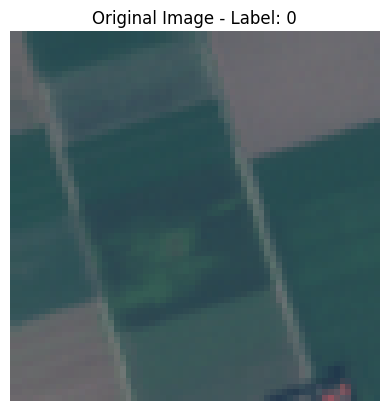

In [12]:
# Depend de CPU ou GPU
num_workers = 6
batch_size = 32

# Image dataset
image_dataloader_test = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "image", data_type = "test")
to_pil = ToPILImage()
image, label = to_pil(next(iter(image_dataloader_test))[0][0]), next(iter(image_dataloader_test))[1][0].item()

plt.imshow(image)
plt.title(f"Original Image - Label: {label}")
plt.axis('off')
plt.savefig(os.path.join(paths["images"], "original_image.png"))
plt.show()

# # Datasets sans effets
# cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "cnn", data_type = "test")
# vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "vit", data_type = "test")

In [13]:
# # Datasets sans effets
# cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "cnn", data_type = "test")
# vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "vit", data_type = "test")

# # Test accuracy CNN sans effets
# acc_cnn = accuracy(cnn_dataloader_test, model_cnn, device)
# print(f"Test Accuracy (CNN): {acc_cnn:.4f}")

# # Test accuracy ViT sans effets
# acc_vit = accuracy(vit_dataloader_test, model_vit, device)
# print(f"Test Accuracy (ViT): {acc_vit:.4f}")

# log_result("no effect", acc_cnn, acc_vit)

In [ ]:
# Datasets avec effets masquage du centre de l'image
mask_percent = [0.2, 0.5, 0.8] 

for mask in mask_percent:
    
    # Appliquer le masque au centre de l'image et sauvegarder l'image
    print(f"\nTesting with {int(mask*100)}% of center of the image masked:")

    # Créer des dataloaders avec l'effet de masque centré
    center_mask_effects = {"center_mask": mask}
    cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "cnn", effects=center_mask_effects)
    vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "vit", effects=center_mask_effects)
    acc_cnn_effects = accuracy(cnn_dataloader, model_cnn, device)
    acc_vit_effects = accuracy(vit_dataloader, model_vit, device)

    print(f"Test Accuracy with {int(mask*100)}% Center-Masked Images (CNN): {acc_cnn_effects:.4f}")
    print(f"Test Accuracy with {int(mask*100)}% Center-Masked Images (ViT): {acc_vit_effects:.4f}")

    log_result(f"{int(mask*100)}_center_masked", acc_cnn_effects, acc_vit_effects)
    
    
    # Appliquer le masque au centre de l'image et sauvegarder l'image
    modified_image = d.apply_center_mask(image, mask)
    #show_image(image, label[0])
    img_path = os.path.join(paths["images"], f"center_mask_img_{int(mask*100)}.png")
    plt.imsave(img_path, modified_image)


Testing with 20% of the image masked:
Test Accuracy with 20% Center-Masked Images (CNN): 0.9683
Test Accuracy with 20% Center-Masked Images (ViT): 0.8861

Testing with 50% of the image masked:
Test Accuracy with 50% Center-Masked Images (CNN): 0.6413
Test Accuracy with 50% Center-Masked Images (ViT): 0.5052

Testing with 80% of the image masked:
Test Accuracy with 80% Center-Masked Images (CNN): 0.1128
Test Accuracy with 80% Center-Masked Images (ViT): 0.1150


In [ ]:
# Datasets avec effets masquage aléatoire de l'image
mask_percent = [0.1, 0.15 0.2] 

for mask in mask_percent:
    
    # Appliquer le masque au centre de l'image et sauvegarder l'image
    print(f"\nTesting with {int(mask*100)}% of random pixels in the image masked:")

    # Créer des dataloaders avec l'effet de masque centré
    random_mask_effects = {"random_mask": mask}
    cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "cnn", effects=random_mask_effects)
    vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "vit", effects=random_mask_effects)
    acc_cnn_effects = accuracy(cnn_dataloader, model_cnn, device)
    acc_vit_effects = accuracy(vit_dataloader, model_vit, device)

    print(f"Test Accuracy with {int(mask*100)}% Random-Masked Images (CNN): {acc_cnn_effects:.4f}")
    print(f"Test Accuracy with {int(mask*100)}% Random-Masked Images (ViT): {acc_vit_effects:.4f}")

    log_result(f"{int(mask*100)}_random_masked", acc_cnn_effects, acc_vit_effects)
    
    # Appliquer le masque au centre de l'image et sauvegarder l'image
    modified_image = d.apply_random_mask(image, mask)
    #show_image(image, label[0])
    img_path = os.path.join(paths["images"], f"random_mask_img_{int(mask*100)}.png")
    plt.imsave(img_path, modified_image)



Testing with 20% of the image masked:
Test Accuracy with 20% Random-Masked Images (CNN): 0.1130
Test Accuracy with 20% Random-Masked Images (ViT): 0.2000

Testing with 50% of the image masked:


KeyboardInterrupt: 

In [ ]:
# Datasets avec effets masquage aléatoire de l'image
gaussian_blur_radii = [1, 5, 10] 

for radius in gaussian_blur_radii:
    
    # Appliquer le masque au centre de l'image et sauvegarder l'image
    print(f"\nTesting with Gaussian Blur Radius {radius}:")

    # Créer des dataloaders avec l'effet de masque centré
    gaussian_blur_effects = {"gaussian_blur": radius}
    cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "cnn", effects=gaussian_blur_effects)
    vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "vit", effects=gaussian_blur_effects)
    acc_cnn_effects = accuracy(cnn_dataloader, model_cnn, device)
    acc_vit_effects = accuracy(vit_dataloader, model_vit, device)

    print(f"Test Accuracy with Gaussian Blur Radius {radius} (CNN): {acc_cnn_effects:.4f}")
    print(f"Test Accuracy with Gaussian Blur Radius {radius} (ViT): {acc_vit_effects:.4f}")

    log_result(f"{radius}_gaussian_blur", acc_cnn_effects, acc_vit_effects)
    
    # Appliquer le masque au centre de l'image et sauvegarder l'image
    image = d.apply_gaussian_blur(image, radius)
    #show_image(image, label[0])
    img_path = os.path.join(paths["images"], f"gaussian_blur_img_{radius}.png")
    plt.imsave(img_path, image)